In [2]:
import torch

In [5]:
torch.zeros(3,3)

tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])

In [12]:
f = lambda x,y : x+y

In [14]:
f(1,2)

3

In [29]:
import torch
import numpy as np

# 创建一个 torch.Tensor（假设在 GPU 上）
tensor = torch.tensor([1.0, 2.0, 3.0], device='cuda')

# 将 GPU tensor 移动到 CPU
tensor_cpu = tensor.to('cpu')

# 将 tensor 转换为 numpy 数组
numpy_array = tensor_cpu.numpy()

# 使用 numpy 函数进行处理
result = np.sqrt(numpy_array)

print("Torch Tensor:", tensor)
print("Numpy Array:", numpy_array)
print("Result after applying numpy function:", result)

AssertionError: Torch not compiled with CUDA enabled

In [77]:
import torch

# 生成示例数据
data_dict = {
    'inputs': torch.randn(100, 3, 32, 32),  # 例如100个32x32的RGB图像
    'labels': torch.randint(0, 10, (100,)),  # 100个随机标签，范围在0到9之间
    'metadata': torch.arange(100)  # 额外的元数据，例如索引
}

# 保存数据到文件
torch.save(data_dict, 'data_dict.pt')

In [89]:
from torch.utils.data import Dataset

class DictDataset(Dataset):
    def __init__(self, path):
        self.data = torch.load(path)

    def __len__(self):
        return len(self.data[list(self.data.keys())[0]])
    
    def __getitem__(self, idx):
        return {
            _param: self.data[_param][idx] for _param in self.data.keys()
        }


In [93]:
from torch.utils.data import DataLoader

# 创建自定义 Dataset
dataset = DictDataset('data_dict.pt')

# 创建 DataLoader
dataloader = DataLoader(dataset, batch_size=100, shuffle=True)

i = 0
# 迭代 DataLoader
for batch in dataloader:
    i += 1
    inputs = batch['inputs']
    labels = batch['labels']
    metadata = batch['metadata']
    print(f'Begin the {i}th iter.')
    print("Batch inputs:", inputs.shape)
    print("Batch labels:", labels)
    print("Batch metadata:", metadata)

Begin the 1th iter.
Batch inputs: torch.Size([100, 3, 32, 32])
Batch labels: tensor([5, 1, 8, 4, 0, 5, 3, 4, 0, 7, 8, 2, 2, 7, 6, 1, 5, 1, 1, 5, 5, 9, 1, 4,
        7, 7, 6, 9, 2, 0, 6, 4, 5, 9, 9, 6, 1, 7, 2, 8, 8, 4, 7, 0, 8, 8, 9, 4,
        7, 6, 5, 3, 5, 3, 3, 3, 5, 0, 5, 2, 4, 1, 3, 0, 8, 6, 9, 1, 4, 7, 1, 7,
        8, 1, 3, 6, 6, 8, 1, 3, 9, 0, 6, 5, 9, 0, 8, 8, 4, 8, 3, 1, 0, 1, 7, 8,
        3, 7, 9, 6])
Batch metadata: tensor([36, 74, 52, 48, 24, 66,  7, 49, 89, 19, 64, 70, 71, 18, 35, 63, 47, 55,
        61, 88, 54, 83, 99,  5, 39, 58,  8, 57, 31, 41, 75, 32,  9, 95,  0, 14,
        40, 11, 68, 78, 97, 15, 67, 56, 77, 91, 93, 20, 33, 42,  4, 51, 82, 26,
        27, 23, 59, 98, 60, 50, 86, 92, 13, 16, 29, 25, 76, 65, 17, 46,  6, 72,
        37, 34, 21, 38, 90, 73, 85, 79, 81,  2, 96, 30, 22,  1, 53, 62, 84, 43,
        28, 12,  3, 10, 45, 87, 44, 69, 80, 94])


In [76]:
batch

{'inputs': tensor([[[[-0.8878, -0.5280,  0.1571,  ..., -0.2808, -0.0331,  0.0818],
           [ 0.5474,  0.5612, -1.4993,  ..., -0.7754,  0.2853, -0.2096],
           [-0.4529,  0.2906, -0.4952,  ...,  0.4406, -3.1002,  0.8245],
           ...,
           [-0.2646,  1.0569, -0.3854,  ...,  0.6995,  0.3297, -0.0245],
           [ 0.4720, -0.9401,  0.7449,  ...,  0.3366,  0.2248,  0.7251],
           [-1.1675,  0.8933,  0.7283,  ...,  2.7504, -0.6177,  0.4153]],
 
          [[ 0.9172, -0.9144,  1.7102,  ...,  2.4420, -1.7069,  0.1822],
           [-1.6621,  0.6032,  0.8857,  ...,  0.8098,  1.4453,  0.9608],
           [-1.0998,  1.5644,  0.7560,  ..., -0.1020, -0.0682, -1.9430],
           ...,
           [-1.0336,  0.3492, -2.0704,  ..., -0.3594, -1.7510,  1.5424],
           [ 1.1361, -0.0157,  1.0471,  ..., -0.6884, -1.7066,  0.6882],
           [ 0.4718, -2.3903, -0.7172,  ..., -0.2150,  0.9472, -0.2996]],
 
          [[ 0.0534, -1.0858,  1.1246,  ..., -1.4638, -1.3288,  0.5966],
   

In [94]:
x = torch.randn(3,3)

In [95]:
a, b = x[:,0:1], x[:,1:1]

In [96]:
a

tensor([[ 0.1427],
        [-0.7871],
        [-0.1565]])

In [99]:
torch.cat([a,b],-1)

tensor([[ 0.1427],
        [-0.7871],
        [-0.1565]])

In [103]:
x = torch.ones(3)

In [122]:
import torch

# 示例数据：两个二维张量
x = torch.tensor([[1, 2, 3], [4, 5, 6]])
y = torch.tensor([[7, 8, 9], [10, 11, 12]])

# 创建二维网格
x_grid, y_grid = torch.meshgrid(x, y, indexing='ij')

print("x_grid:\n", x_grid)
print("y_grid:\n", y_grid)

RuntimeError: torch.meshgrid: Expected 0D or 1D tensor in the tensor list but got:  1  2  3
 4  5  6
[ torch.LongTensor{2,3} ]

In [121]:
torch.randn(3).T - torch.randn(4,3)

tensor([[ 1.5044,  1.5890,  0.4441],
        [-0.1163,  1.8807, -1.8963],
        [ 0.9823,  0.4542, -2.1945],
        [-0.8877,  2.3493,  0.1210]])

In [2]:
int(10/1)

10

In [130]:
x.unsqueeze(0)

tensor([[[-0.5687,  0.2368,  0.9420],
         [ 0.1780,  0.1297, -0.5389],
         [ 0.2828,  2.1941,  1.3216]]])

In [131]:
x.repeat(2,1,1)

tensor([[[-0.5687,  0.2368,  0.9420],
         [ 0.1780,  0.1297, -0.5389],
         [ 0.2828,  2.1941,  1.3216]],

        [[-0.5687,  0.2368,  0.9420],
         [ 0.1780,  0.1297, -0.5389],
         [ 0.2828,  2.1941,  1.3216]]])

In [135]:
x.repeat_interleave(2,0)

tensor([[-0.5687,  0.2368,  0.9420],
        [-0.5687,  0.2368,  0.9420],
        [ 0.1780,  0.1297, -0.5389],
        [ 0.1780,  0.1297, -0.5389],
        [ 0.2828,  2.1941,  1.3216],
        [ 0.2828,  2.1941,  1.3216]])

In [1]:

import torch

In [25]:
x = torch.load("/home/ycui/Documents/deepOnet_bermudan/data/free_test_num_ex_12_qmax_0.05_sensor_type_MP_num_sensor_50_var_rescale_2/test/test_0.pt", map_location="cpu")

In [3]:
x["q"].max()

tensor(0.0494, device='cuda:0')

In [26]:
x["solution"]

tensor([[2.3269e+00, 1.9055e+00, 2.3897e+00,  ..., 6.6659e-01, 4.1324e-01,
         4.2535e+00],
        [1.7057e+00, 1.1039e+00, 2.5014e+00,  ..., 1.5251e+00, 2.1043e+00,
         4.1426e+00],
        [1.4106e+00, 9.2365e-01, 2.0598e+00,  ..., 5.0932e+00, 5.3446e-07,
         2.6594e+00],
        ...,
        [2.1941e+00, 2.3693e+00, 1.6640e+00,  ..., 3.0803e+00, 6.2674e+00,
         2.6985e-06],
        [8.0534e-01, 7.2146e-01, 1.1259e+00,  ..., 3.8792e-04, 1.0114e+00,
         2.4736e+00],
        [7.4101e-01, 1.1317e+00, 1.0867e+00,  ..., 1.1047e-02, 9.7363e-04,
         8.5314e-01]], dtype=torch.float64)

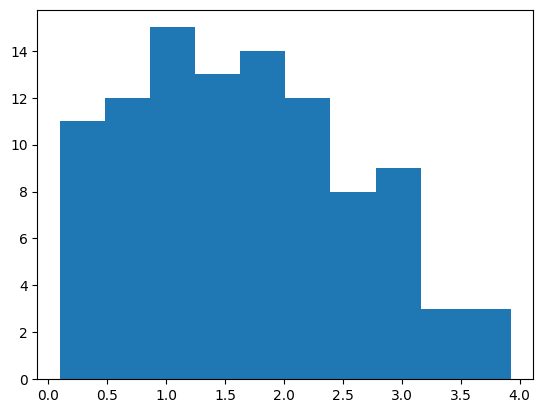

In [23]:
import matplotlib.pyplot as plt

plt.hist(x["solution"].flatten().cpu())
plt.show()

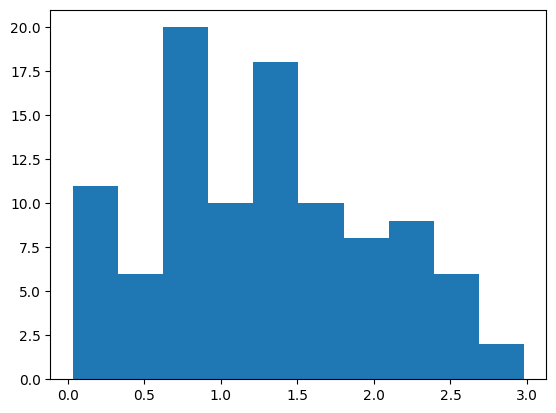

In [25]:
import matplotlib.pyplot as plt

plt.hist(x["solution"].flatten().cpu())
plt.show()

In [5]:
for _p in x:
    print(f"The {_p} is {x[_p][0]}")

The payoff is tensor([9.5051, 9.0837, 8.6630, 8.2429, 7.8234, 7.4045, 6.9861, 6.5682, 6.1508,
        5.7339, 5.3174, 4.9013, 4.4856, 4.0702, 3.6551, 3.2403, 2.8257, 2.4114,
        1.9972, 1.5833, 1.1695, 0.7558, 0.5572, 0.3981, 0.2586, 0.0000, 0.0000,
        0.0855, 0.4673, 0.8055, 0.9962, 0.9925, 0.8020, 0.4745, 0.0815, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.4149, 0.9672, 1.3934, 1.3024, 0.4326], device='cuda:0')
The y is tensor([1.4215], device='cuda:0', dtype=torch.float64)
The t is tensor([0.0833], device='cuda:0')
The s is tensor([9.4719], device='cuda:0')
The r is tensor([0.0105], device='cuda:0')
The q is tensor([0.0390], device='cuda:0')
The sigma is tensor([0.5971], device='cuda:0')
The kappa is tensor([1.0046], device='cuda:0')
The K is tensor([9.5151], device='cuda:0')
The x is tensor([9.4719], device='cuda:0')
The solution is tensor([2.3269, 1.9055, 2.3897, 2.3981, 3.4081, 0.3126, 0.7692, 2.4369, 4.3089,
        

In [11]:
x["x"][100]

tensor([10.3655], device='cuda:0')

In [15]:
from deep_kolmogorov import trainer,utils
import torch


In [18]:
config = {
  "T": 1,
  "accu_steps": 10,
  "bermudan": "Bermudan_1D",
  "bs_test": 100,
  "bs_train": 10000,
  "checkpoint": True,
  "data_path": "/home/ycui/Documents/deepOnet_bermudan/data/free_test_num_ex_12_qmax_0.05_sensor_type_MP_num_sensor_200_var_rescale_2",
  "factor": 6,
  "frezed_params": {
    "t": 0
  },
  "gpus": 0,
  "interp_method": "linear",
  "kernel": "RBF",
  "length_scale": 10,
  "levels": 4,
  "lr": 0.01,
  "lr_decay": 0.25,
  "lr_decay_patience": 2,
  "min_lr": 1e-08,
  "mode": "avg_bs_bermudan_put_free_test_num_ex_12_qmax_0.05_sensor_type_MP_num_sensor_200_var_rescale_2",
  "n_iterations": 30,
  "n_test_batches": 1000,
  "n_train_batches": 20000,
  "net": "DNN",
  "norm_layer": "layernorm",
  "num_depth": 5,
  "num_ex": 12,
  "num_width": 35,
  "opt": "adamw",
  "option_type": "put",
  "output_params": [
    "x",
    "r",
    "q",
    "sigma",
    "K"
  ],
  "payoff": "GRF",
  "pde": "BSr",
  "seed": 0,
  "sensor": torch.from_numpy(utils.MP_grid(n=200,g1=50,g2=50)).float(),
  "size_sensor": 200,
  "size_t_x_u": [
    0,
    1,
    4
  ],
  "unfreeze": "all",
  "unfreeze_patience": 1,
  "var_scale": 1,
  "weight_decay": 0.01
}

In [19]:
mytrainer = trainer.Trainer(config)
path = "/home/ycui/Documents/deepOnet_bermudan/exp/avg_bs_bermudan_put_free_test_num_ex_12_qmax_0.05_sensor_type_MP_num_sensor_200_var_rescale_2_2024_07_08_13_36_47/Trainer_2024-07-08_13-36-47/Trainer_1167c_00000_0_num_depth=5,num_width=35,seed=0_2024-07-08_13-36-47/checkpoint_000009/model.pth"
mytrainer.load_checkpoint(path)


/home/ycui/.conda/envs/torch/lib/python3.10/site-packages/ray/tune/trainable/trainable.py:1080: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
`UnifiedLogger` will be removed in Ray 2.7.
  self._result_logger = UnifiedLogger(config, self._logdir, loggers=None)
/home/ycui/.conda/envs/torch/lib/python3.10/site-packages/ray/tune/logger/unified.py:53: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
The `JsonLogger interface is deprecated in favor of the `ray.tune.json.JsonLoggerCallback` interface and will be removed in Ray 2.7.
  self._loggers.append(cls(self.config, self.logdir, self.trial))
/home/ycui/.conda/envs/torch/lib/python3.10/site-packages/ray/tune/logger/unified.py:53: RayDeprecationWarning: This API

100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100


2024-07-09 10:39:45,543	INFO trainable.py:172 -- Trainable.setup took 593.910 seconds. If your trainable is slow to initialize, consider setting reuse_actors=True to reduce actor creation overheads.


100


In [48]:
res = {"bermudan": [], "net":[]}
for batch in mytrainer.test_loader:
    _res = mytrainer.model.forward(batch, train=False)
    res["bermudan"].append(_res["bermudan"])
    res["net"].append(_res["net"])
res = {_k:torch.concat(res[_k], dim=0) for _k in res.keys()}


100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100
100


tensor([[2.2680e+00, 1.8949e+00, 2.3386e+00,  ..., 6.8820e-01, 4.4047e-01,
         4.1880e+00],
        [1.7001e+00, 1.1454e+00, 2.4133e+00,  ..., 1.5105e+00, 2.0953e+00,
         4.1038e+00],
        [1.4041e+00, 9.4660e-01, 1.9957e+00,  ..., 4.9851e+00, 0.0000e+00,
         2.6279e+00],
        ...,
        [2.1794e+00, 2.3497e+00, 1.6853e+00,  ..., 3.0574e+00, 6.1934e+00,
         0.0000e+00],
        [8.1723e-01, 7.3416e-01, 1.1112e+00,  ..., 3.2964e-04, 9.8674e-01,
         2.4258e+00],
        [7.4309e-01, 1.1430e+00, 1.1003e+00,  ..., 1.2366e-02, 0.0000e+00,
         8.5821e-01]])

In [49]:
for i in range(y.shape[-1]):
    print((abs(res["bermudan"][:,i] - res["net"][:,i])/(res["bermudan"][:,i] + 1)).mean())

tensor(0.0143, dtype=torch.float64)
tensor(0.0180, dtype=torch.float64)
tensor(0.0197, dtype=torch.float64)
tensor(0.0202, dtype=torch.float64)
tensor(0.0201, dtype=torch.float64)
tensor(0.0192, dtype=torch.float64)
tensor(0.0175, dtype=torch.float64)
tensor(0.0157, dtype=torch.float64)
tensor(0.0132, dtype=torch.float64)
tensor(0.0107, dtype=torch.float64)
tensor(0.0083, dtype=torch.float64)
tensor(0.0063, dtype=torch.float64)


In [1]:
(abs(res["bermudan"] - res["net"])/(res["bermudan"] + 1)).std()

NameError: name 'res' is not defined

In [45]:
for i in range(y.shape[-1]):
    _id = (x["x"][100*i:100*(i+1),0]<=10).tolist() and (x["x"][100*i:100*(i+1),0]>=9).tolist()
    print((abs(x["solution"][_id,i] - y[_id,i])/(x["solution"][_id,i] + 1)).mean())

tensor(0.0136, dtype=torch.float64)
tensor(0.0176, dtype=torch.float64)
tensor(0.0187, dtype=torch.float64)
tensor(0.0218, dtype=torch.float64)
tensor(0.0233, dtype=torch.float64)
tensor(0.0234, dtype=torch.float64)
tensor(0.0185, dtype=torch.float64)
tensor(0.0194, dtype=torch.float64)
tensor(0.0170, dtype=torch.float64)
tensor(0.0121, dtype=torch.float64)
tensor(0.0074, dtype=torch.float64)
tensor(0.0045, dtype=torch.float64)


In [11]:
import os
import random
import torch
import ray
from ray import tune
from datetime import datetime
from argparse import ArgumentParser
from deep_kolmogorov.modeling import Metrics, KolmogorovNet, NETS, NORMLAYERS
from deep_kolmogorov.pdes import HYPERCUBES, PDES
from deep_kolmogorov.bermudan import BERMUDANS, Data_Saved
from torch.utils.data import DataLoader
from deep_kolmogorov.payoff import PAYOFFS

In [12]:
OPTIMIZERS = {
    "adamw": lambda params, lr, weight_decay: torch.optim.AdamW(
        params, lr=lr, weight_decay=weight_decay
    ),
    "sgd": lambda params, lr, weight_decay: torch.optim.SGD(
        params, lr=lr, momentum=0.9, weight_decay=weight_decay
    ),
}

In [15]:
pde_kwargs = (
            {"hypercubes": HYPERCUBES[config["hypercubes"]]}
            if "hypercubes" in config
            else {}
        )
pde = PDES[config["pde"]](**pde_kwargs)
net = NETS[config["net"]](config)
payoff_kwargs = {
    _arg: config[_arg] for _arg in ["sensor", "kernel", "length_scale", "var_scale"] if _arg in config.keys()
    }
payoff = PAYOFFS[config["payoff"]](**payoff_kwargs)
bermudan = BERMUDANS[config["bermudan"]](pde, payoff, config)
saved_data = True if config["data_path"] else False
model = KolmogorovNet(net, bermudan, saved_data=saved_data)

In [16]:
net.params_groups

[{'params': <generator object Module.parameters at 0x7f33289c29d0>}]

In [17]:
opt = OPTIMIZERS[config["opt"]](
            net.params_groups, lr=config["lr"], weight_decay=config["weight_decay"]
        )

In [18]:
net.params_groups

[{'params': [Parameter containing:
   tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
           1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
           1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
           1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
           1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
           1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
           1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
           1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
           1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
           1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
           1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
           1., 1., 1., 1., 1., 1.], requires_grad=Tr

In [2]:
import torch

from deep_kolmogorov import utils
a = torch.from_numpy(utils.MP_grid())

In [3]:
b = 10*torch.exp(torch.linspace(-2.1,2.1, 200))

In [5]:
b.dtype

torch.float32

In [6]:
a.dtype

torch.float64

In [9]:
torch.from_numpy(utils.MP_grid()).float()

tensor([1.0000e-02, 5.2207e-01, 1.0214e+00, 1.5086e+00, 1.9844e+00, 2.4494e+00,
        2.9042e+00, 3.3494e+00, 3.7857e+00, 4.2137e+00, 4.6338e+00, 5.0467e+00,
        5.4530e+00, 5.8531e+00, 6.2477e+00, 6.6371e+00, 7.0221e+00, 7.4031e+00,
        7.7805e+00, 8.1550e+00, 8.5269e+00, 8.8969e+00, 9.2655e+00, 9.6330e+00,
        1.0000e+01, 1.0669e+01, 1.1349e+01, 1.2054e+01, 1.2795e+01, 1.3586e+01,
        1.4441e+01, 1.5375e+01, 1.6404e+01, 1.7548e+01, 1.8826e+01, 2.0261e+01,
        2.1879e+01, 2.3708e+01, 2.5782e+01, 2.8136e+01, 3.0813e+01, 3.3861e+01,
        3.7334e+01, 4.1294e+01, 4.5810e+01, 5.0965e+01, 5.6848e+01, 6.3566e+01,
        7.1238e+01, 8.0000e+01])